This notebook is to prep for my interview with an undisclosed company in Adtech
- Date: June 19th, 2026

# Prep
## Imports

In [53]:
## if running into errors with pip, add to PATH
# import sys, os
# print(os.path.dirname(sys.executable))


In [54]:
!pip install -r ../requirements.txt
# !python -m pip freeze > requirements.txt


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import sklearn
import seaborn as sns
import scipy
from scipy import stats
# import scikit-learn

## Constants

In [56]:
DATA_PATH = "../data/"
AOV = 80

## Load in Data

In [57]:
campaign_df = pd.read_csv(DATA_PATH + "campaign_performance.csv")
print(campaign_df.shape[0])
campaign_df.head(3)

4288


,date,campaign_id,campaign_name,channel,region,weather_severity_index,impressions,clicks,spend_cad,conversions,revenue_cad,cpm_cad,cpc_cad,roas
0,2025-12-22,CMP1002,Premium_Upgrade_Q1,Connected TV,Quebec,0.871,48337,951.5,702.84,22.10,1481.14,14.54,0.739,2.107
1,2025-11-29,CMP1004,Brand_Lift_National,Connected TV,Quebec,0.374,36764,539.9,248.47,25.07,1746.93,6.76,0.460,7.031
2,2025-12-11,CMP1006,Spring_Forecast_Launch,Display,British Columbia,0.982,83195,1353.7,759.46,56.94,2276.05,9.13,0.561,2.997


In [58]:
users_df = pd.read_csv(DATA_PATH + "users.csv")
print(users_df.shape[0])
users_df.head(3)

3010


,user_id,signup_date,acquisition_channel,region,plan_type,avg_monthly_sessions,alerts_enabled,push_notifications_enabled,tenure_months,churned,churn_date,ltv_cad
0,U100452,2024-12-10,Native,Atlantic,Free,0.85,1,0,12.90,0,NaN,0.0
1,U101657,2025-11-24,Referral,Ontario,Free,5.90,1,1,1.27,0,NaN,0.0
2,U100062,2024-12-03,Organic,Ontario,Premium,0.27,0,0,13.13,0,NaN,304.5


In [59]:
adtech_df = pd.read_excel(DATA_PATH + "adtech_practice_dataset.xlsx")
print(adtech_df.shape[0])
adtech_df.head(3)

4288


,date,campaign_id,campaign_name,channel,region,weather_severity_index,impressions,clicks,spend_cad,conversions,revenue_cad,cpm_cad,cpc_cad,roas
0,2025-12-22,CMP1002,Premium_Upgrade_Q1,Connected TV,Quebec,0.871,48337,951.5,702.84,22.10,1481.14,14.54,0.739,2.107
1,2025-11-29,CMP1004,Brand_Lift_National,Connected TV,Quebec,0.374,36764,539.9,248.47,25.07,1746.93,6.76,0.460,7.031
2,2025-12-11,CMP1006,Spring_Forecast_Launch,Display,British Columbia,0.982,83195,1353.7,759.46,56.94,2276.05,9.13,0.561,2.997


# Day 1 analysis
- Derive Adtech metrics (Revenue, CPM, CPC, ROAS) 
- Compare to precalculated ones (revenue_cad, cpm_cad, cpc_cad, roas)
- EDA

In [60]:
campaign_base_df = campaign_df[['date', 'impressions', 'clicks', 'spend_cad', 'conversions', 'campaign_id', 'campaign_name', 'channel', 'region', 'weather_severity_index']]

campaign_base_df.head(1)

,date,impressions,clicks,spend_cad,conversions,campaign_id,campaign_name,channel,region,weather_severity_index
0,2025-12-22,48337,951.5,702.84,22.1,CMP1002,Premium_Upgrade_Q1,Connected TV,Quebec,0.871


## 1.1 Understanding the data, what I'm being given, some context.

In [61]:
campaign_base_df.describe()

,impressions,clicks,spend_cad,conversions,weather_severity_index
count,4.288000e+03,4245.000000,4267.000000,4288.000000,4288.000000
mean,6.014057e+04,903.015940,551.677874,36.409611,0.605392
std,6.635299e+04,544.908681,471.167486,27.569856,0.228200
min,5.000000e+02,6.400000,-542.140000,0.230000,0.105000
25%,4.366350e+04,539.900000,321.355000,17.915000,0.405000
50%,5.532200e+04,810.100000,457.200000,30.230000,0.632000
75%,6.743800e+04,1138.500000,624.240000,47.765000,0.781000
max,2.125964e+06,5426.700000,6599.410000,357.890000,1.000000


- Good to note how some of the data ranges, like Clicks varies from ~6 - ~5400, vs Weather is 0.10 - 1.00.
- Knowing the data format helps us analyze it accordingly, like weather is a percentage.

In [62]:
campaign_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4288 entries, 0 to 4287
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    4288 non-null   str    
 1   campaign_id             4288 non-null   str    
 2   campaign_name           4288 non-null   str    
 3   channel                 4288 non-null   str    
 4   region                  4254 non-null   str    
 5   weather_severity_index  4288 non-null   float64
 6   impressions             4288 non-null   int64  
 7   clicks                  4245 non-null   float64
 8   spend_cad               4267 non-null   float64
 9   conversions             4288 non-null   float64
 10  revenue_cad             4288 non-null   float64
 11  cpm_cad                 4288 non-null   float64
 12  cpc_cad                 4203 non-null   float64
 13  roas                    4288 non-null   float64
dtypes: float64(8), int64(1), str(5)
memory usage: 469.1

In [63]:
users_df.describe()

,avg_monthly_sessions,alerts_enabled,push_notifications_enabled,tenure_months,churned,ltv_cad
count,2980.000000,3010.000000,3010.000000,3010.00000,3010.000000,2995.000000
mean,7.088003,0.713621,0.544186,10.11986,0.229900,76.230317
std,5.287196,0.452144,0.498127,5.33177,0.420838,130.630449
min,0.100000,0.000000,0.000000,1.07000,0.000000,0.000000
25%,3.310000,0.000000,0.000000,5.50000,0.000000,0.000000
50%,5.930000,1.000000,1.000000,9.97000,0.000000,0.000000
75%,9.310000,1.000000,1.000000,14.76000,0.000000,115.365000
max,50.760000,1.000000,1.000000,19.30000,1.000000,1015.600000


## 1.2 Make Adtech metrics

In [64]:
# # impressions, clicks, spend_cad, conversions
# # CPM = Cost per 1000 impressions, so CPM = spend / impressions * 1000
campaign_df['CPM'] = (campaign_base_df['spend_cad'] / campaign_base_df['impressions']) * 1000

# CPC - Cost per click, so CPC = spend / clicks 
campaign_df['CPC'] = campaign_base_df['spend_cad'] / campaign_base_df['clicks']

# CTR - Click Through Rate, so CTR = clicks / impressions

In [65]:
# # Revenue = Conversions * average order value (AOV), assume this has been calculated, and is a constant
campaign_df['Revenue CAD'] = campaign_base_df['conversions'] * AOV


# # ROAS - Return on Ad Spend, so ROAS = revenue / spend 
campaign_df['ROAS'] = campaign_df['Revenue CAD'] / campaign_base_df['spend_cad']


In [66]:
# tidy up:

campaign_df['CPM']          = campaign_df['CPM'].round(2)
campaign_df['CPC']          = campaign_df['CPC'].round(2)
campaign_df['Revenue CAD']  = campaign_df['Revenue CAD'].round(2)
campaign_df['ROAS']         = campaign_df['ROAS'].round(3)

campaign_df.head(3)

,date,campaign_id,campaign_name,channel,region,weather_severity_index,impressions,clicks,spend_cad,conversions,revenue_cad,cpm_cad,cpc_cad,roas,CPM,CPC,Revenue CAD,ROAS
0,2025-12-22,CMP1002,Premium_Upgrade_Q1,Connected TV,Quebec,0.871,48337,951.5,702.84,22.10,1481.14,14.54,0.739,2.107,14.54,0.74,1768.0,2.516
1,2025-11-29,CMP1004,Brand_Lift_National,Connected TV,Quebec,0.374,36764,539.9,248.47,25.07,1746.93,6.76,0.460,7.031,6.76,0.46,2005.6,8.072
2,2025-12-11,CMP1006,Spring_Forecast_Launch,Display,British Columbia,0.982,83195,1353.7,759.46,56.94,2276.05,9.13,0.561,2.997,9.13,0.56,4555.2,5.998


In [67]:
check_metrics_df = pd.DataFrame()
check_metrics_df ["CPM Check"] = campaign_df["CPM"] - campaign_df["cpm_cad"]
check_metrics_df ["CPC Check"] = campaign_df["CPC"] - campaign_df["cpc_cad"]
check_metrics_df ["Revenue Check"] = campaign_df["Revenue CAD"] - campaign_df["revenue_cad"]
check_metrics_df ["ROAS Check"] = campaign_df["ROAS"] - campaign_df["roas"]

check_metrics_df.head(5)

,CPM Check,CPC Check,Revenue Check,ROAS Check
0,0.0,0.001,286.86,0.409
1,0.0,0.000,258.67,1.041
2,0.0,-0.001,2279.15,3.001
3,0.0,0.001,-106.95,-0.556
4,0.0,0.001,256.53,1.061


- So here we see the CPM and CPC are calculated well!
- The Revenue is off, but that is fine, as we used a AOV value that was static and estimated.

In [68]:
# Remove old data:
campaign_df.drop(columns=['cpm_cad', 'cpc_cad', 'revenue_cad', 'roas'])
campaign_df.head(2)

,date,campaign_id,campaign_name,channel,region,weather_severity_index,impressions,clicks,spend_cad,conversions,revenue_cad,cpm_cad,cpc_cad,roas,CPM,CPC,Revenue CAD,ROAS
0,2025-12-22,CMP1002,Premium_Upgrade_Q1,Connected TV,Quebec,0.871,48337,951.5,702.84,22.10,1481.14,14.54,0.739,2.107,14.54,0.74,1768.0,2.516
1,2025-11-29,CMP1004,Brand_Lift_National,Connected TV,Quebec,0.374,36764,539.9,248.47,25.07,1746.93,6.76,0.460,7.031,6.76,0.46,2005.6,8.072


## 1.3 Data quality checking
### 1.3.1 Missing data

In [69]:
print(campaign_df.columns)
print(users_df.columns)

Index(['date', 'campaign_id', 'campaign_name', 'channel', 'region',
       'weather_severity_index', 'impressions', 'clicks', 'spend_cad',
       'conversions', 'revenue_cad', 'cpm_cad', 'cpc_cad', 'roas', 'CPM',
       'CPC', 'Revenue CAD', 'ROAS'],
      dtype='str')
Index(['user_id', 'signup_date', 'acquisition_channel', 'region', 'plan_type',
       'avg_monthly_sessions', 'alerts_enabled', 'push_notifications_enabled',
       'tenure_months', 'churned', 'churn_date', 'ltv_cad'],
      dtype='str')


In [70]:
cols_to_check_campaign = ['date', 'campaign_id', 'campaign_name', 'channel', 'region',
       'weather_severity_index', 'impressions', 'clicks']
cols_to_check_users = ['user_id', 'signup_date', 'acquisition_channel', 'region', 'plan_type',
       'avg_monthly_sessions', 'alerts_enabled', 'push_notifications_enabled',
       'tenure_months', 'churned', 'churn_date', 'ltv_cad']

In [71]:
# want to make functions to measure missing data, NANs, null, so on.
def analyze_missing_in_col(df, colName):
    num_nulls = df[colName].isnull().sum()
    if num_nulls > 0:
        print( f"# of missing values in {colName} is {num_nulls}")

print("for df `campaign_df`")
for col in cols_to_check_campaign:
    analyze_missing_in_col(campaign_df, col)

print("for df `users_df`")
for col in cols_to_check_users:
    analyze_missing_in_col(users_df, col)

for df `campaign_df`
# of missing values in region is 34
# of missing values in clicks is 43
for df `users_df`
# of missing values in region is 30
# of missing values in avg_monthly_sessions is 30
# of missing values in churn_date is 2318
# of missing values in ltv_cad is 15


In [72]:
null_counts = campaign_df.isnull().sum()
null_pct = (campaign_df.isnull().mean() * 100).round(2)
pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct}).query('null_count > 0')


,null_count,null_pct
region,34,0.79
clicks,43,1.00
spend_cad,21,0.49
cpc_cad,85,1.98
CPM,21,0.49
CPC,43,1.00
ROAS,21,0.49


Visualize the data missing:

<Axes: >

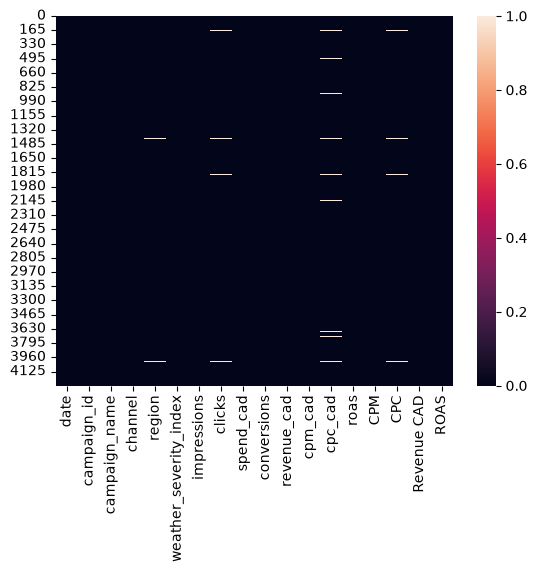

In [73]:
sns.heatmap(campaign_df.isnull())

<Axes: >

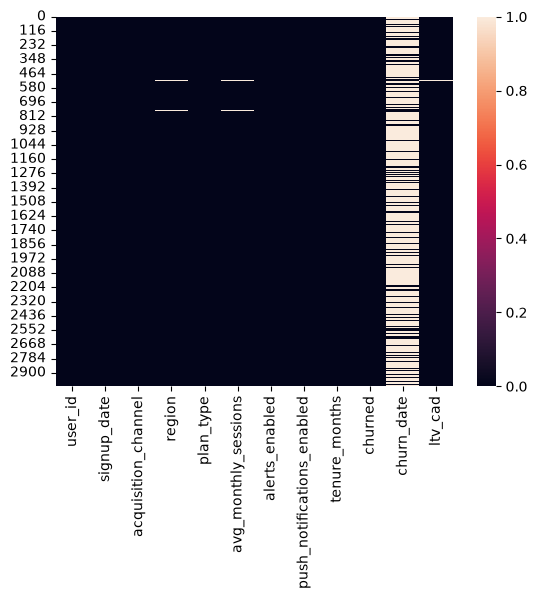

In [74]:
sns.heatmap(users_df.isnull())

- Now we know where the data is missing, we can think about this:
- Do we drop, impute, or flag?



#### 1.3.1 B Handle Missing Data
- for now, just drop all rows with missing data, if it isnt churn_data

In [75]:
# ## so we have detected missing data in Region and Clicks! for campaign df
# for missingCol in ['region', 'clicks']:
#     campaign_df
# ## and we have Region, Avg Monthly sessions, and Churn_data have missing data in users_df.
# for missingCol in ['region', 'avg_monthly_sessions', 'ltv_cad']:
#     users_df

### 1.3.2. Duplicates

In [76]:
# to find dupes, I'm using the ID columns.
print(f"Looking into the # of duplicate campaigns in campaign_df:\t{campaign_df.duplicated(subset=['campaign_id', 'campaign_name']).sum()}")
print(f"and the size of campaign_df is {campaign_df.shape[0]}")

print(f"Looking into the # of duplicate users in users_df:\t\t{users_df.duplicated(subset=['user_id']).sum()}")
print(f"and the size of campaign_df is {users_df.shape[0]}")



Looking into the # of duplicate campaigns in campaign_df:	4280
and the size of campaign_df is 4288
Looking into the # of duplicate users in users_df:		10
and the size of campaign_df is 3010


In [77]:
campaign_df_clean = campaign_df.drop_duplicates()
print(f"Now the size of campaign_df is {campaign_df_clean.shape[0]}")


Now the size of campaign_df is 4274


### 1.3.3. Outliers

In [78]:
# Look at the relationship between impressions and clicks. 
    # Are there rows where this relationship looks implausible (e.g. very high impressions, very low click-through)? 
    # What real-world phenomenon could cause this?
    # To me, this could read as ad fraud / bot traffic
# Choose a detection method — z-score, IQR, percentile threshold, or just eyeballing a scatter plot first?
# Would you drop these rows, cap them (winsorize), or flag them as a separate segment? Justify your choice.


In [79]:
campaign_df.head(1)

,date,campaign_id,campaign_name,channel,region,weather_severity_index,impressions,clicks,spend_cad,conversions,revenue_cad,cpm_cad,cpc_cad,roas,CPM,CPC,Revenue CAD,ROAS
0,2025-12-22,CMP1002,Premium_Upgrade_Q1,Connected TV,Quebec,0.871,48337,951.5,702.84,22.1,1481.14,14.54,0.739,2.107,14.54,0.74,1768.0,2.516


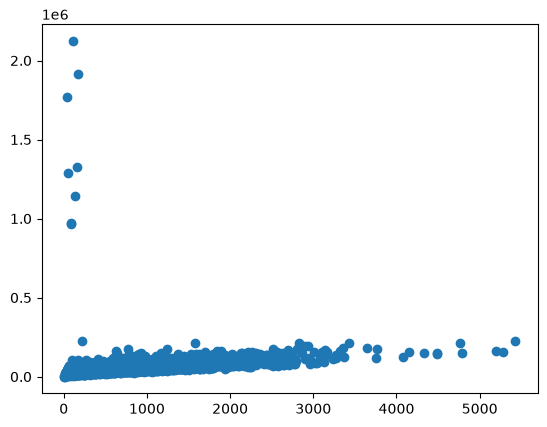

In [80]:
# First up, let's just do a scatter plot of impressions vs clicks
# this is just to eyeball anomalies quick
fig, ax = plt.subplots()

ax.scatter(campaign_df["clicks"], campaign_df["impressions"])

plt.show()

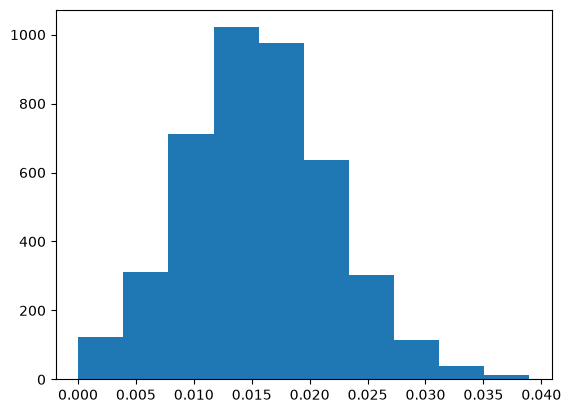

In [81]:
# Add CTR (clicks/impressions) column, and plot a distribution (histogram)
campaign_df["CTR"] = campaign_df["clicks"] / campaign_df["impressions"]

plt.hist(campaign_df["CTR"])

plt.show()


In [ ]:
## Need to add more here, like zscore outlier detection, or another outlier detection method.
## rn we are just seeing there are outliers, but not handling them appropriately

# Remove outliers from the 'CTR' column using Z-scores
# Z-score on CTR, handling NaN/inf from the missing/zero-click rows first
ctr_clean = campaign_df['CTR'].replace([np.inf, -np.inf], np.nan)
z_scores = np.abs(stats.zscore(ctr_clean, nan_policy='omit'))

campaign_df['CTR Outlier'] = z_scores > 3
print('Flagged outlier rows:', campaign_df['CTR Outlier'].sum())
campaign_df[campaign_df['CTR Outlier']][['date', 'campaign_name', 'channel', 'impressions', 'clicks', 'CTR']]
outliers = campaign_df.loc[campaign_df['CTR Outlier']!=False]
outliers.head(10)

Flagged outlier rows: 18


,date,campaign_id,campaign_name,channel,region,weather_severity_index,impressions,clicks,spend_cad,conversions,revenue_cad,cpm_cad,cpc_cad,roas,CPM,CPC,Revenue CAD,ROAS,CTR,CTR Outlier
397,2026-04-05,CMP1003,Severe_Weather_Awareness,Connected TV,Ontario,0.569,78827,2962.6,518.98,163.26,7506.79,6.58,0.175,14.464,6.58,0.18,13060.8,25.166,0.037584,True
656,2026-01-05,CMP1007,B2B_Partner_Coop,Connected TV,Atlantic,0.640,61901,2237.2,466.17,100.34,12200.05,7.53,0.208,26.171,7.53,0.21,8027.2,17.219,0.036142,True
703,2026-03-12,CMP1006,Spring_Forecast_Launch,Display,Quebec,0.555,63486,2219.8,491.79,139.98,13674.83,7.75,0.222,27.806,7.75,0.22,11198.4,22.771,0.034965,True
826,2025-11-25,CMP1002,Premium_Upgrade_Q1,native,Alberta,0.388,76079,2634.3,419.86,78.13,5733.13,5.52,0.159,13.655,5.52,0.16,6250.4,14.887,0.034626,True
901,2026-02-22,CMP1000,Winter_Storm_Alert_Promo,Connected TV,British Columbia,0.625,85982,3014.4,860.40,59.56,6357.03,10.01,0.285,7.388,10.01,0.29,4764.8,5.538,0.035059,True
1200,2026-01-01,CMP1003,Severe_Weather_Awareness,Connected TV,Atlantic,0.954,74414,2653.7,436.42,69.75,3055.75,5.86,NaN,7.002,5.86,0.16,5580.0,12.786,0.035661,True
1295,2026-03-07,CMP1007,B2B_Partner_Coop,Connected TV,British Columbia,0.496,62580,2252.0,592.10,94.12,4839.39,9.46,0.263,8.173,9.46,0.26,7529.6,12.717,0.035986,True
1324,2026-02-07,CMP1006,Spring_Forecast_Launch,Connected TV,Ontario,0.895,47043,1642.1,752.12,112.62,12631.59,15.99,0.458,16.795,15.99,0.46,9009.6,11.979,0.034906,True
1343,2026-01-09,CMP1005,Local_News_Sponsorship,Connected TV,Ontario,0.879,35454,1245.5,241.75,59.07,4147.05,6.82,0.194,17.154,6.82,0.19,4725.6,19.547,0.035130,True
1358,2026-02-02,CMP1006,Spring_Forecast_Launch,Connected TV,Alberta,0.952,46617,1745.3,378.12,85.65,6798.53,8.11,0.217,17.980,8.11,0.22,6852.0,18.121,0.037439,True


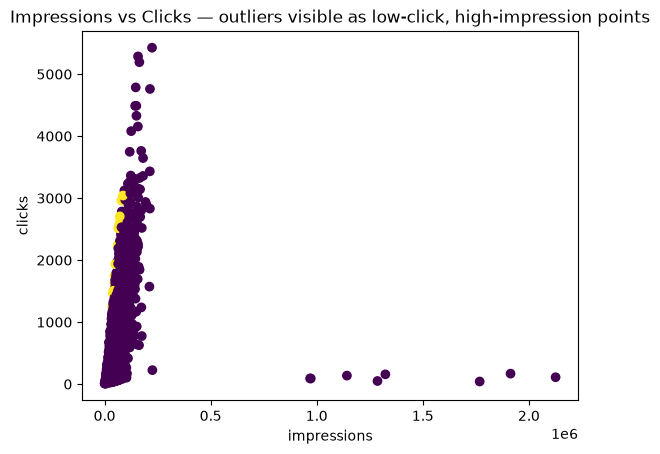

In [87]:
colors = campaign_df["CTR Outlier"].astype(int)

plt.scatter(campaign_df['impressions'], campaign_df['clicks'], c=colors)
plt.xlabel('impressions')
plt.ylabel('clicks')
plt.title('Impressions vs Clicks — outliers visible as low-click, high-impression points')
plt.show()

plt.show()

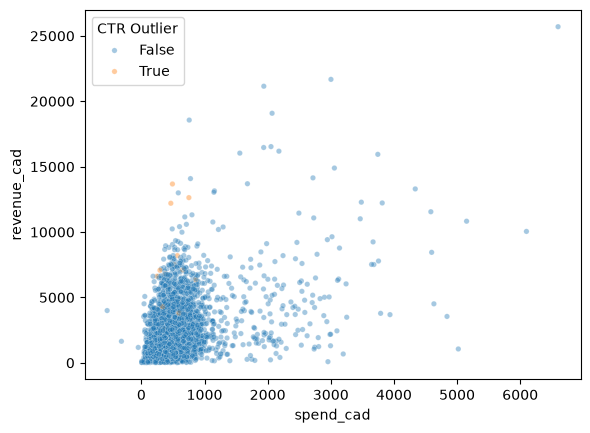

In [85]:
sns.scatterplot(data=campaign_df, x='spend_cad', y='revenue_cad', 
                hue='CTR Outlier', alpha=0.4, s=15)
plt.show()


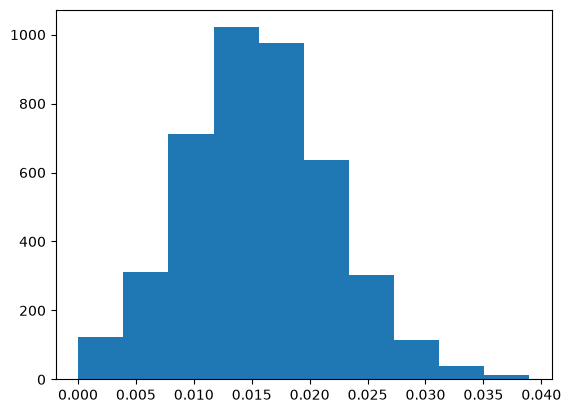

In [ ]:
plt.hist(campaign_df["CTR"])
plt.show()

### 1.3.4. Inconsistent categorical values

In [ ]:
# Guiding questions:
# Check unique values in `channel` and `region`. Do you see inconsistent casing or stray whitespace?
# How would you normalize these in a production pipeline vs. just for this notebook?
campaign_df["channel"].value_counts()

channel
Video           878
Search          870
Display         865
Connected TV    829
Native          803
video            15
native            9
display           8
search            7
connected tv      4
Name: count, dtype: int64

In [ ]:
map_Channel_normalization = {
    'video'			: 'Video',
	'native'		: 'Native',
	'display'		: 'Display',
	'search'		: 'Search',
	'connected tv'	: 'Connected TV',
    'Video'			: 'Video',
	'Native'		: 'Native',
	'Display'		: 'Display',
	'Search'		: 'Search',
	'Connected Tv'	: 'Connected TV',
}
campaign_df["channel"] = campaign_df["channel"].map(map_Channel_normalization)
campaign_df["channel"].value_counts()
# n

channel
Video           893
Search          877
Display         873
Native          812
Connected TV      4
Name: count, dtype: int64

In [ ]:
campaign_df["region"].value_counts()

region
Atlantic              870
British Columbia      859
Alberta               836
Ontario               829
Quebec                817
Atlantic               13
Quebec                  9
Alberta                 9
Ontario                 8
British Columbia        4
Name: count, dtype: int64

In [ ]:
campaign_df["region"] = campaign_df["region"].str.strip()
campaign_df["region"].value_counts()


region
Atlantic            883
British Columbia    863
Alberta             845
Ontario             837
Quebec              826
Name: count, dtype: int64

### 1.3.5. Invalid values
- like negative spending

In [ ]:
def checkNumNegVals (df, colName):
    return len(df.loc[df[colName] < 0].index)
cols_that_cant_be_negative = ['spend_cad', 'impressions', 'clicks', 'conversions']
for col in cols_that_cant_be_negative:
    print(f"For {col}, there are {checkNumNegVals(campaign_df, col)} negative values")

negative_rows = campaign_df.loc[campaign_df['spend_cad'] < 0]
negative_rows


For spend_cad, there are 3 negative values
For impressions, there are 0 negative values
For clicks, there are 0 negative values
For conversions, there are 0 negative values


,date,campaign_id,campaign_name,channel,region,weather_severity_index,impressions,clicks,spend_cad,conversions,revenue_cad,cpm_cad,cpc_cad,roas,CPM,CPC,Revenue CAD,ROAS,CTR,CTR Outlier
1235,2026-01-11,CMP1007,B2B_Partner_Coop,Video,Ontario,0.837,49799,550.7,-49.80,13.67,1177.66,1.00,0.090,23.648,-1.00,-0.09,1093.6,-21.960,0.011058,False
2111,2026-01-28,CMP1005,Local_News_Sponsorship,Video,Atlantic,0.886,57755,977.9,-542.14,46.62,3995.93,9.39,0.554,7.371,-9.39,-0.55,3729.6,-6.879,0.016932,False
2587,2026-01-01,CMP1004,Brand_Lift_National,Display,Ontario,0.954,46959,823.6,-316.08,27.28,1645.09,6.73,0.384,5.205,-6.73,-0.38,2182.4,-6.905,0.017539,False


2 fair approaches to handling this data:
1. Treat negative values as 0. Reading: negative spend means they were paid for the campaign, so no cost.
2. Convert negatives to positive. Reading: the negatives were placed by mistake, these are simply written wrong.

## 1.4 Clean Data

In [ ]:
# Here is where we actually tidy the code, and make changes to make a new df.
# Drop exact duplicates
campaign_df_clean = campaign_df.drop_duplicates()

# Impute region nulls, we can make an Unknown category
campaign_df_clean['region'] = campaign_df_clean['region'].fillna('Unknown')

# Drop rows missing clicks or spend (small %, core to every metric)
campaign_df_clean = campaign_df_clean.dropna(subset=['clicks', 'spend_cad'])

# Recompute CPC/CTR cleanly now that clicks/spend are non-null
campaign_df_clean['CPC'] = campaign_df_clean['spend_cad'] / campaign_df_clean['clicks']
campaign_df_clean['CTR'] = campaign_df_clean['clicks'] / campaign_df_clean['impressions']

# Exclude flagged CTR outliers from the "modeling-ready" frame, but keep the flag for reference
campaign_df_clean = campaign_df_clean[~campaign_df_clean['CTR Outlier']]

print('Original shape:', campaign_df.shape)
print('Cleaned shape:', campaign_df_clean.shape)
campaign_df_clean.head(3)


Original shape: (4288, 20)
Cleaned shape: (4212, 20)


,date,campaign_id,campaign_name,channel,region,weather_severity_index,impressions,clicks,spend_cad,conversions,revenue_cad,cpm_cad,cpc_cad,roas,CPM,CPC,Revenue CAD,ROAS,CTR,CTR Outlier
0,2025-12-22,CMP1002,Premium_Upgrade_Q1,NaN,Quebec,0.871,48337,951.5,702.84,22.10,1481.14,14.54,0.739,2.107,14.54,0.738665,1768.0,2.516,0.019685,False
1,2025-11-29,CMP1004,Brand_Lift_National,NaN,Quebec,0.374,36764,539.9,248.47,25.07,1746.93,6.76,0.460,7.031,6.76,0.460215,2005.6,8.072,0.014686,False
2,2025-12-11,CMP1006,Spring_Forecast_Launch,Display,British Columbia,0.982,83195,1353.7,759.46,56.94,2276.05,9.13,0.561,2.997,9.13,0.561025,4555.2,5.998,0.016271,False


# Day 2 analysis
## Univariate visualizations

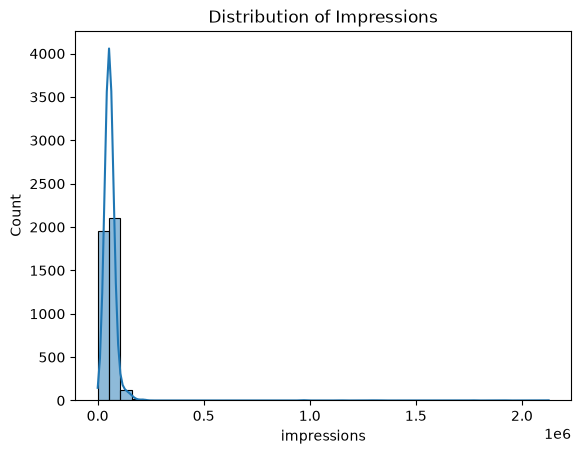

In [ ]:
sns.histplot(campaign_df_clean['impressions'], bins=40, kde=True) #kde shows the probablity density estimate
plt.title('Distribution of Impressions')
plt.show()
# Right-skewed, as expected for impressions/spend data -- a log transform would help if used as a model feature.


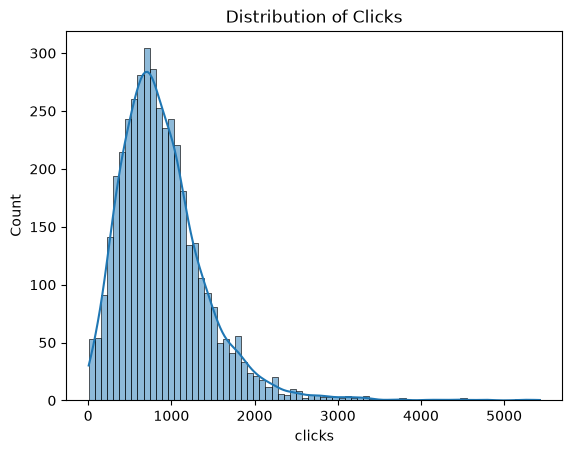

In [ ]:
sns.histplot(campaign_df_clean['clicks'], kde=True) #kde shows the probablity density estimate
plt.title('Distribution of Clicks')
plt.show()


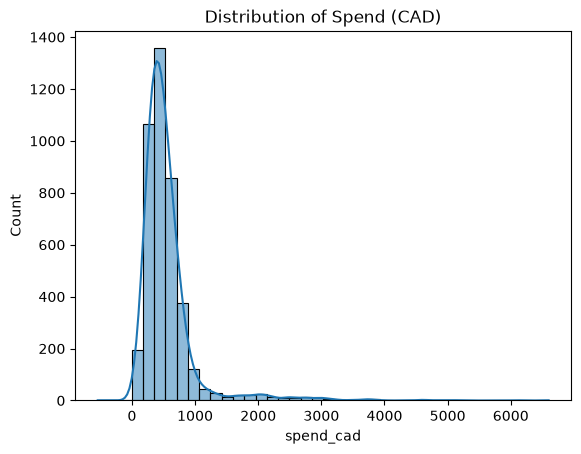

In [ ]:
sns.histplot(campaign_df_clean['spend_cad'], bins=40, kde=True)
plt.title('Distribution of Spend (CAD)')
plt.show()

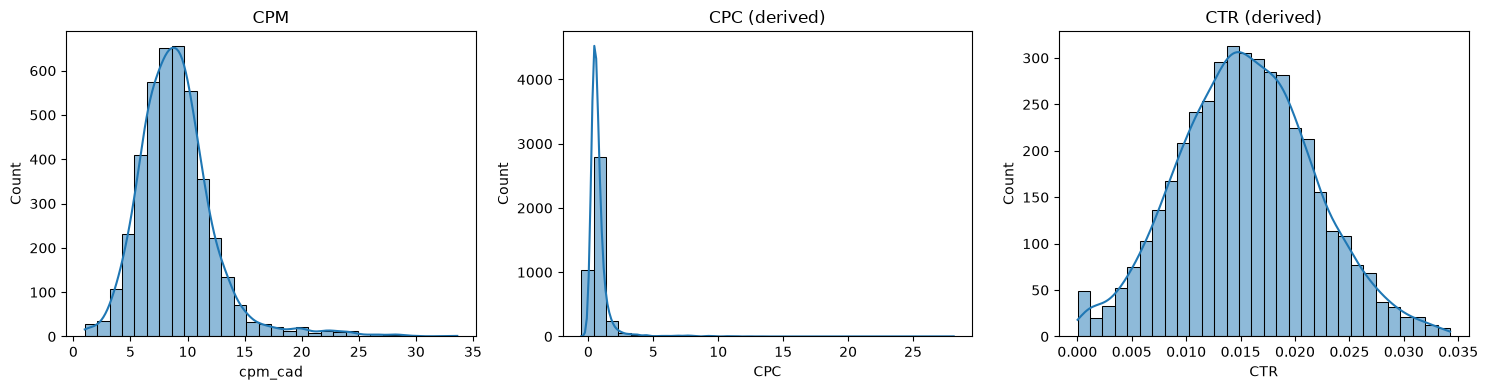

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(campaign_df_clean['cpm_cad'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('CPM')
sns.histplot(campaign_df_clean['CPC'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('CPC (derived)')
sns.histplot(campaign_df_clean['CTR'], bins=30, kde=True, ax=axes[2])
axes[2].set_title('CTR (derived)')
plt.tight_layout()
plt.show()

<Axes: ylabel='channel'>

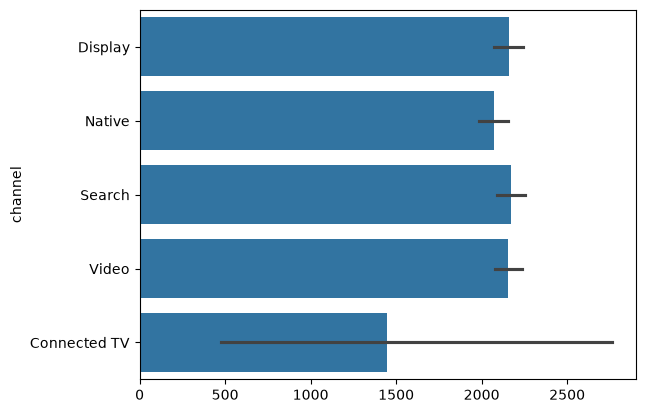

In [ ]:
sns.barplot(campaign_df_clean['channel'])

<Axes: ylabel='region'>

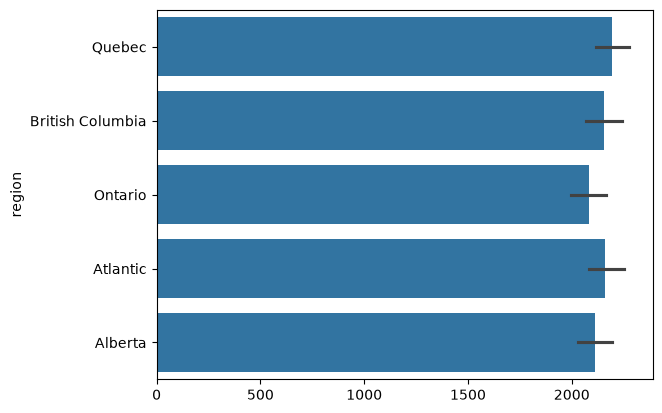

In [ ]:
sns.barplot(campaign_df_clean['region'])


In [ ]:
spend_by_campaign = campaign_df_clean.groupby('campaign_name')['spend_cad'].sum().sort_values(ascending=False)
spend_by_campaign

campaign_name
Severe_Weather_Awareness    343030.08
Winter_Storm_Alert_Promo    330584.34
Brand_Lift_National         279747.07
Premium_Upgrade_Q1          278330.38
Local_News_Sponsorship      278279.37
App_Download_Push           272814.57
Spring_Forecast_Launch      271829.84
B2B_Partner_Coop            270025.39
Name: spend_cad, dtype: float64

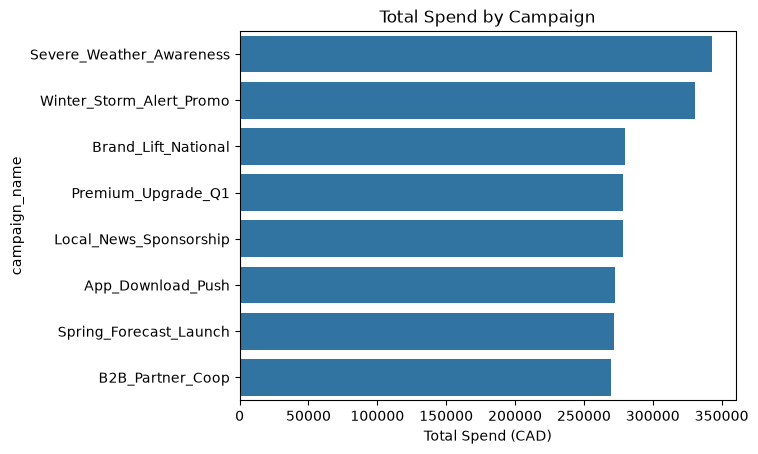

In [ ]:
sns.barplot(x=spend_by_campaign.values, y=spend_by_campaign.index)
plt.title('Total Spend by Campaign')
plt.xlabel('Total Spend (CAD)')
plt.show()


## Bivariate Visualizations
- Where do relationships look roughly linear vs. non-linear?
- Do any relationships differ meaningfully *by group* (e.g. by channel)? This is often more interesting than the pooled relationship.


Text(0.5, 1.0, 'Spend vs Revenue')

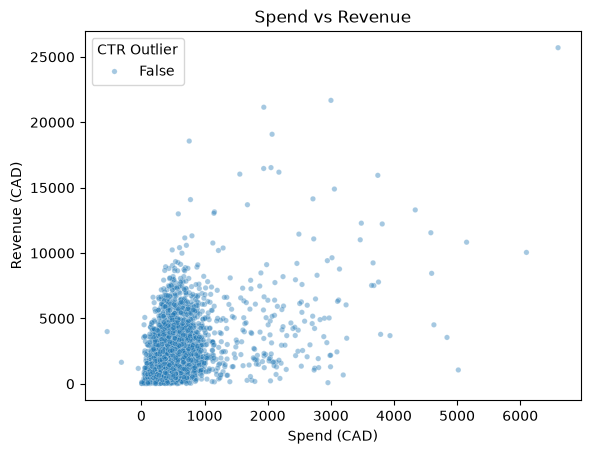

In [ ]:
# Scatter plot of spend_cad vs revenue_cad
# Where do the outliers from Step 3 fall on this plot?
sns.scatterplot(data=campaign_df_clean, x='spend_cad', y='revenue_cad', alpha=0.4, s=15, hue='CTR Outlier')
plt.xlabel('Spend (CAD)')
plt.ylabel('Revenue (CAD)')
plt.title('Spend vs Revenue')


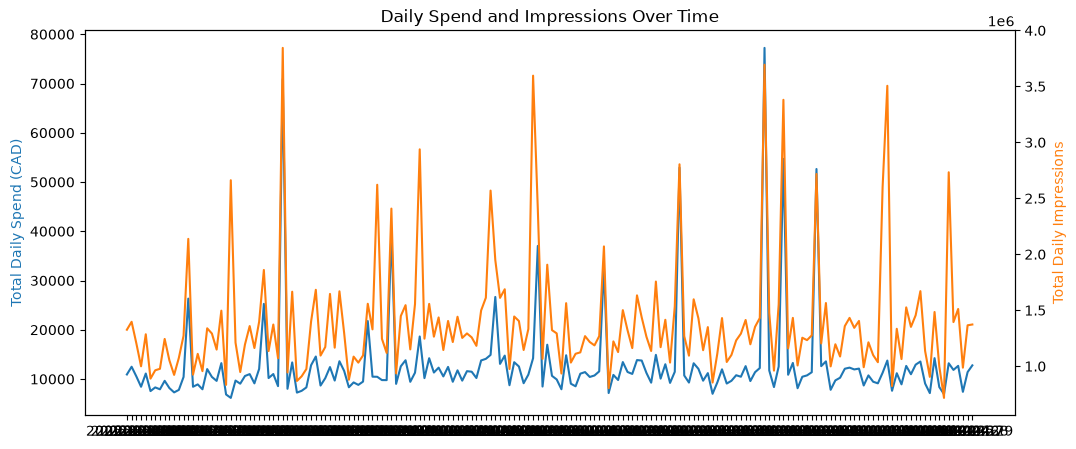

In [ ]:
# time series -- daily total spend and daily total impressions over the 6-month window
# Can you visually spot any anomalous spike days? What might explain them (news cycle shocks)?
daily = campaign_df_clean.groupby('date')[['spend_cad', 'impressions']].sum().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(daily['date'], daily['spend_cad'], color='tab:blue', label='Spend')
ax1.set_ylabel('Total Daily Spend (CAD)', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(daily['date'], daily['impressions'], color='tab:orange', label='Impressions')
ax2.set_ylabel('Total Daily Impressions', color='tab:orange')
plt.title('Daily Spend and Impressions Over Time')
plt.show()
# Spike days visible -- candidates for the "news shock" days baked into the data generation.


In [ ]:
campaign_df_clean.head()

,date,campaign_id,campaign_name,channel,region,weather_severity_index,impressions,clicks,spend_cad,conversions,revenue_cad,cpm_cad,cpc_cad,roas,CPM,CPC,Revenue CAD,ROAS,CTR,CTR Outlier
0,2025-12-22,CMP1002,Premium_Upgrade_Q1,NaN,Quebec,0.871,48337,951.5,702.84,22.10,1481.14,14.54,0.739,2.107,14.54,0.738665,1768.0,2.516,0.019685,False
1,2025-11-29,CMP1004,Brand_Lift_National,NaN,Quebec,0.374,36764,539.9,248.47,25.07,1746.93,6.76,0.460,7.031,6.76,0.460215,2005.6,8.072,0.014686,False
2,2025-12-11,CMP1006,Spring_Forecast_Launch,Display,British Columbia,0.982,83195,1353.7,759.46,56.94,2276.05,9.13,0.561,2.997,9.13,0.561025,4555.2,5.998,0.016271,False
3,2025-12-29,CMP1007,B2B_Partner_Coop,Native,Quebec,0.631,28025,393.2,192.39,14.20,1242.95,6.86,0.489,6.461,6.86,0.489293,1136.0,5.905,0.014030,False
4,2026-01-25,CMP1001,App_Download_Push,NaN,Ontario,0.644,27829,163.5,241.77,7.48,341.87,8.69,1.479,1.414,8.69,1.478716,598.4,2.475,0.005875,False


<Axes: >

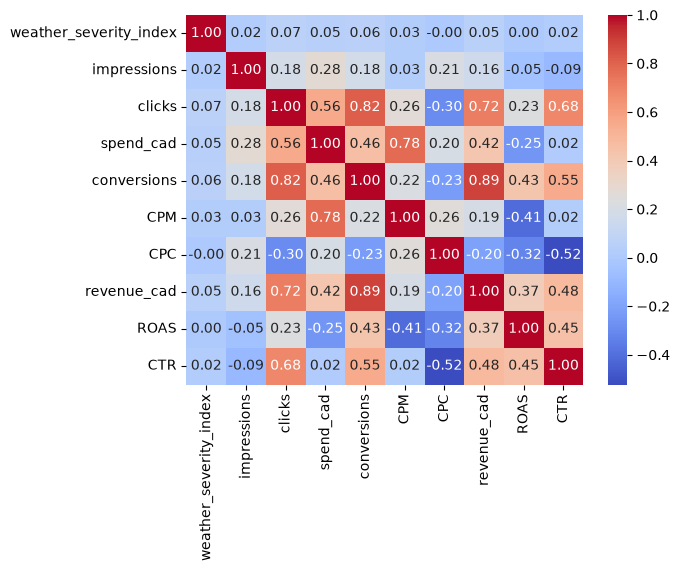

In [ ]:
# Correlation heatmap across the core numeric columns
# Which relationships are strongest? Any surprising near-zero correlations?
numeric_cols =['weather_severity_index','impressions','clicks','spend_cad','conversions','CPM','CPC','revenue_cad','ROAS','CTR']
sns.heatmap(data = campaign_df_clean[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')